In [ ]:
!pip install ultralytics datasets huggingface_hub


In [ ]:
from datasets import load_dataset
from huggingface_hub import snapshot_download
from huggingface_hub import login
from getpass import getpass
#github no permite versionar el archivo si tiene tokens (x defecto tiene activado política de Push Protection y Secret Scanning)
token_sololectura = getpass("Introduce tu token de Hugging Face: ")
login(token=token_sololectura)
repo_path = snapshot_download("YashJain/UI-Elements-Detection-Dataset", repo_type="dataset")
print("Dataset descargado en:", repo_path)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 3787 files:   0%|          | 0/3787 [00:00<?, ?it/s]

Dataset descargado en: /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c


In [ ]:
print("Dataset descargado en:", repo_path)


Dataset descargado en: /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c


In [ ]:
import os

yaml_content = f"""
train: {repo_path}/train/images
val: {repo_path}/val/images
test: {repo_path}/test/images
names:
  0: link
  1: button
  2: input
  3: select
  4: textarea
  5: label
  6: checkbox
  7: radio
  8: dropdown
  9: slider
  10: toggle
  11: menu_item
  12: clickable
  13: icon
  14: image
  15: text
nc: 16
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ Archivo data.yaml creado en", os.getcwd())

✅ Archivo data.yaml creado en /content


In [ ]:
#ENTRENAMIENTO YOLO V8
from ultralytics import YOLO
# Cargar modelo base
model = YOLO("yolov8n.pt")  # tambien se puede usar yolov8s.pt, yolov8m.pt
# Entrenar
model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640, #se probó con 1920 y la sesión falló porque se usó toda la Ram disponible, por ese motivo le cambie a 640
    batch=16,
    workers=2
)

Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78df32f5e930>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2866.3±545.2 MB/s, size: 773.2 KB)
val: Scanning /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c/val/labels.cache... 71 images, 0 backgrounds, 30 corrupt: 100% ━━━━━━━━━━━━ 71/71 141.1Kit/s 0.0s
val: /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c/val/images/dashboards_www.splunk.com_1729626953.png: ignoring corrupt image/label: Label class 8 exceeds dataset class count 6. Possible class labels are 0-5
val: /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c/val/images/design_www.behance.net_1729626894.png: ignoring corrupt image/label: La


image 1/1 /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c/test/images/mostvisited_ft.com_1729631392.png: 320x640 39 links, 3 buttons, 6.7ms
Speed: 2.6ms preprocess, 6.7ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/train114


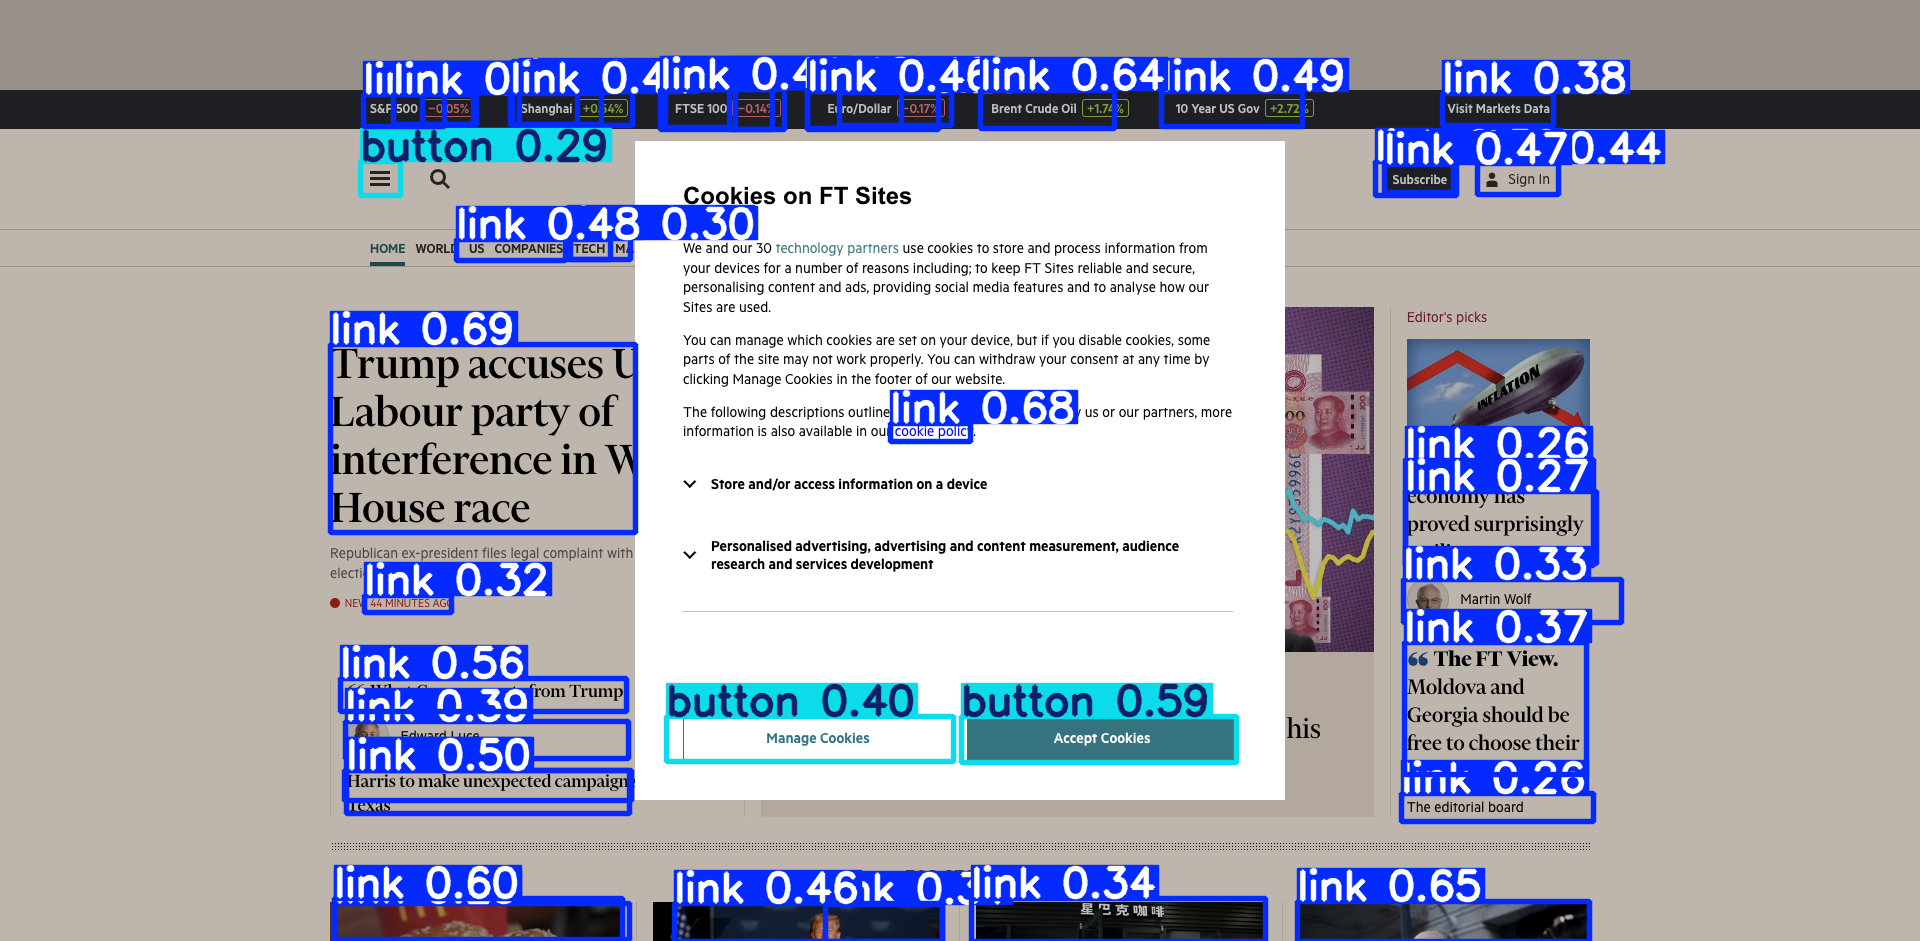

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'link', 1: 'button', 2: 'input', 3: 'select', 4: 'textarea', 5: 'label', 6: 'checkbox', 7: 'radio', 8: 'dropdown', 9: 'slider', 10: 'toggle', 11: 'menu_item', 12: 'clickable', 13: 'icon', 14: 'image', 15: 'text'}
obb: None
orig_img: array([[[138, 145, 151],
        [138, 145, 151],
        [138, 145, 151],
        ...,
        [138, 145, 151],
        [138, 145, 151],
        [138, 145, 151]],

       [[138, 145, 151],
        [138, 145, 151],
        [138, 145, 151],
        ...,
        [138, 145, 151],
        [138, 145, 151],
        [138, 145, 151]],

       [[138, 145, 151],
        [138, 145, 151],
        [138, 145, 151],
        ...,
        [138, 145, 151],
        [138, 145, 151],
        [138, 145, 151]],

       ...,

       [[173, 181, 190],
        [173, 181, 190],
        [173, 181, 190],
        ...,
        [173, 181, 190],


In [ ]:
import random

test_img_dir = os.path.join(repo_path, "test/images")
test_img = os.path.join(test_img_dir, random.choice(os.listdir(test_img_dir)))

results = model(test_img, save=True, conf=0.25)
res = results[0] if isinstance(results, list) else results
res.show()
print(res)


In [ ]:
from google.colab import files

# Descargar el modelo entrenado
files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>